In [1]:
# Please uncomment this out when you are running this lab on google colab!
import os

# Set KaggleHub cache to a directory inside /content/
os.environ["KAGGLEHUB_CACHE"] = "/content/data"

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/segmentation")

print("Path to dataset files:", path)

100%|██████████| 192M/192M [00:10<00:00, 19.6MB/s]

Extracting files...


Path to dataset files: /content/data/datasets/mohammad2012191/segmentation/versions/1


In [3]:
import os
import pandas as pd
from PIL import Image
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import numpy as np
# Custom Dataset Class
import os
import glob
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

In [4]:
def remap_mask(mask):
    # Remaps a mask's pixel values to a consecutive range starting at 0
    mask = mask.long()
    unique_values = torch.unique(mask)
    remapped_mask = torch.zeros_like(mask)

    for new_val, old_val in enumerate(sorted(unique_values.tolist())):
        remapped_mask[mask == old_val] = new_val

    return remapped_mask

# ⏰ Dataset class

In [5]:


class SegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None, target_transform=None):
        self.image_paths = glob.glob(os.path.join(image_dir, "*.jpg"))  # Get all image paths
        self.mask_paths = glob.glob(os.path.join(mask_dir, "*.png"))  # Get all mask paths

        self.image_paths.sort()
        self.mask_paths.sort()

        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # 🔹 Load the image and mask
        image = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")

        # 🔹 Apply transformations for image
        if self.transform:
            image = self.transform(image)

        # 🔹 Apply transformations for mask
        if self.target_transform:
            mask = self.target_transform(mask)

        mask = remap_mask(mask)

        return image, mask  # Return image-mask pair


In [7]:
from torch.utils.data import DataLoader


img_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])



target_transforms = transforms.Compose([                    ## Notice how we have a transform for the target (because it is an image)
    transforms.Resize((256, 256)),                          ##        and another one for the image itself.
    transforms.PILToTensor(),                                                                         ## Question: What do you think would happen if we
                                                            ##  added rotation augmentation to the image only?
])


train_img_path = os.path.join(path, "train/images")
train_msk_path = os.path.join(path, "train/masks")


test_img_path = os.path.join(path, "val/images")
test_msk_path = os.path.join(path, "val/masks")



train_dataset = SegDataset(train_img_path, train_msk_path , transform= img_transforms , target_transform= target_transforms)
test_dataset = SegDataset(test_img_path, test_msk_path , transform= img_transforms , target_transform= target_transforms)


def collate_fn(batch):
    images, masks = zip(*batch)




train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

# Check dataset sizes
print(f"Training Samples: {len(train_dataset)}, Testing Samples: {len(test_dataset)}")

Training Samples: 1737, Testing Samples: 435


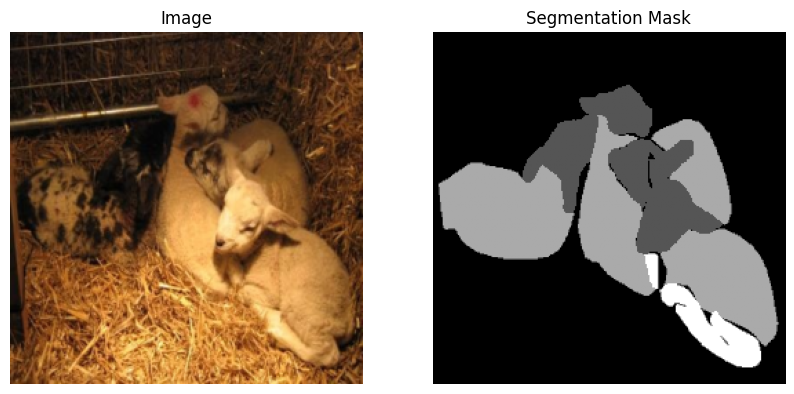

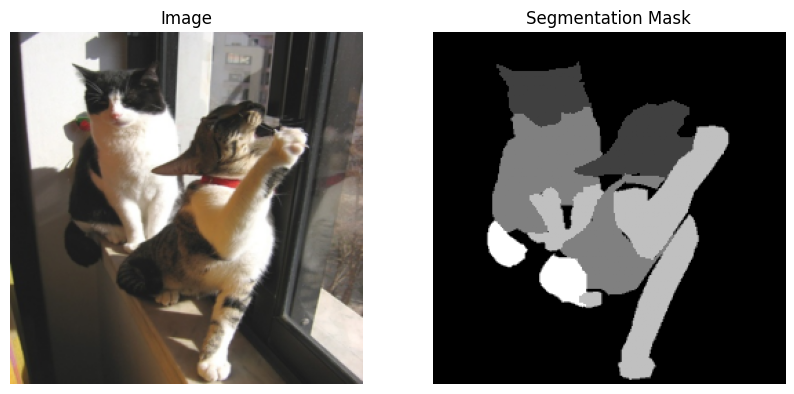

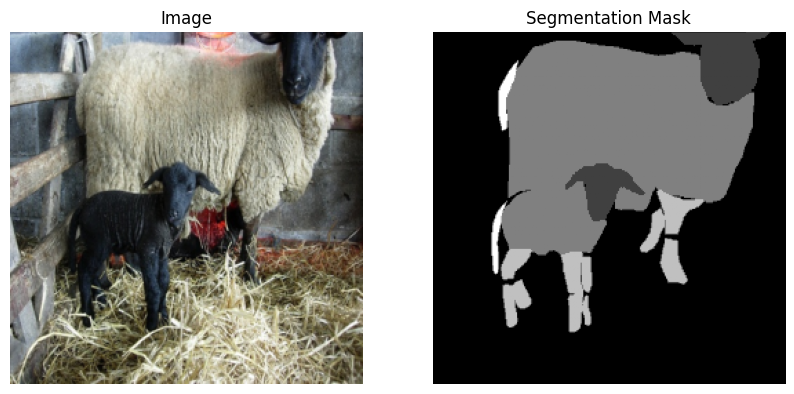

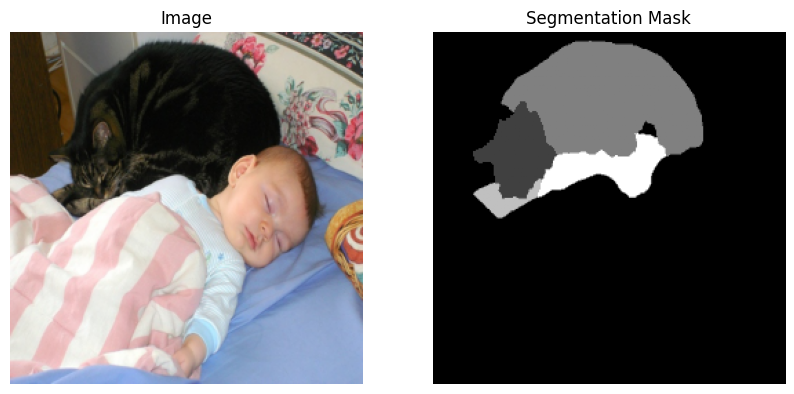

In [9]:
import matplotlib.pyplot as plt

# Display some images with their masks
for i in range(11,15):
    img, mask = train_dataset[i]
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img.permute(1, 2, 0))  # Convert (C, H, W) to (H, W, C)
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")
    plt.show()

# ⏰ Model U-Net

In [10]:
!pip install -q segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.9 MB/s eta 0:00:00


In [11]:
import segmentation_models_pytorch as smp

# Define U-Net Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="efficientnet-b0",  # Pretrained encoder (backbone)
    encoder_weights="imagenet",  # Use ImageNet weights
    in_channels=3,  # RGB images
    classes=5,  # How many object we try to classify (cat , dog .... , background)
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

# ⏰ Training and Validation

In [32]:
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm

# 🔹 Training Loop
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for images, masks in tqdm(dataloader):
        images, masks = images.to(device), masks.to(device).to(torch.long)

        outputs = model(images)
        loss = criterion(outputs, masks.squeeze(1)) # Explicitly squeeze channel dimension

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

# 🔹 Validation Loop
def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images, masks = images.to(device), masks.to(device).to(torch.long)

            outputs = model(images)
            loss = criterion(outputs, masks.squeeze(1)) # Explicitly squeeze channel dimension
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [33]:
import torch
from torch import nn
# Define loss function and optimizer
# criterion = nn.BCEWithLogitsLoss() This only for binary classification
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

num_epochs = 10  # Define number of epochs
train_losses = []
val_losses = []

# Training Loop
for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = validate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

100%|██████████| 435/435 [00:33<00:00, 13.01it/s]


Epoch 1/10: Train Loss = 0.4604, Val Loss = 0.3504


100%|██████████| 435/435 [00:32<00:00, 13.48it/s]


Epoch 2/10: Train Loss = 0.3671, Val Loss = 0.3369


100%|██████████| 435/435 [00:32<00:00, 13.51it/s]


...

Epoch 8/10: Train Loss = 0.2189, Val Loss = 0.2778


100%|██████████| 435/435 [00:32<00:00, 13.48it/s]


Epoch 9/10: Train Loss = 0.1987, Val Loss = 0.2769


100%|██████████| 435/435 [00:34<00:00, 12.62it/s]


Epoch 10/10: Train Loss = 0.1941, Val Loss = 0.2915


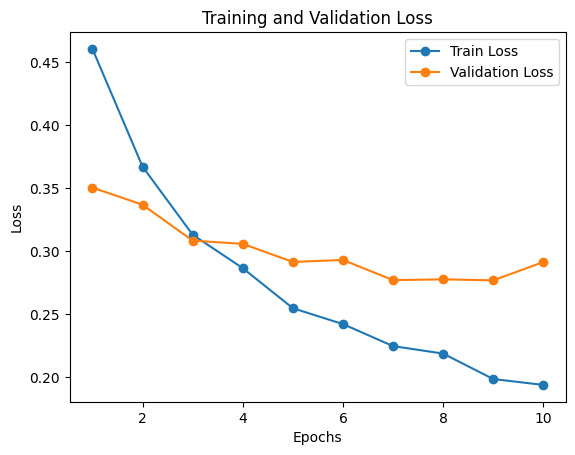

In [34]:
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs+1), train_losses, label="Train Loss", marker='o')
plt.plot(range(1, num_epochs+1), val_losses, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

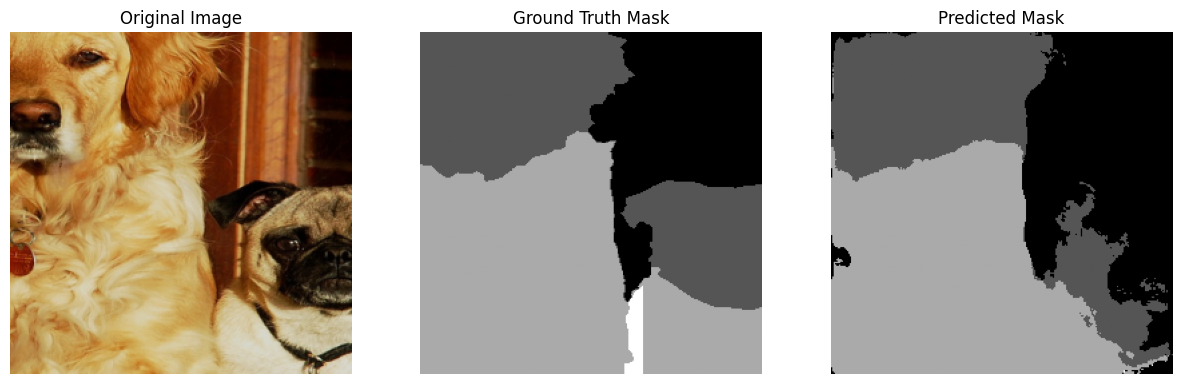

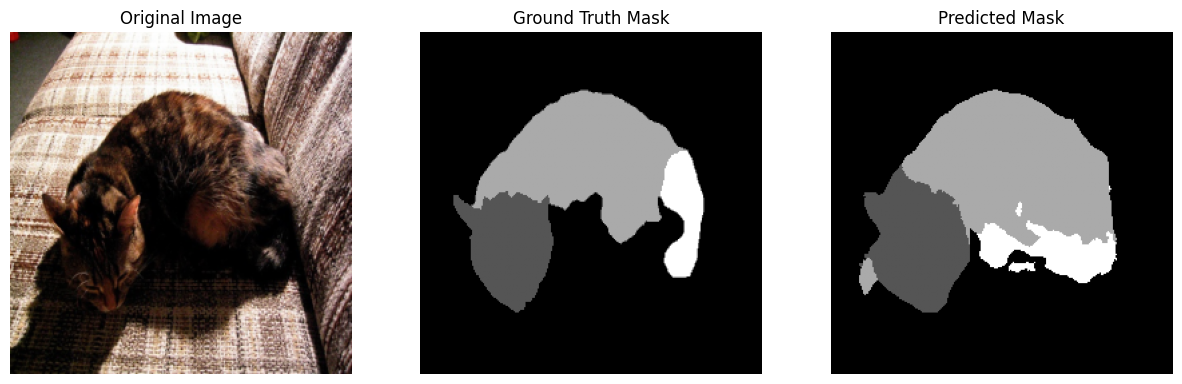

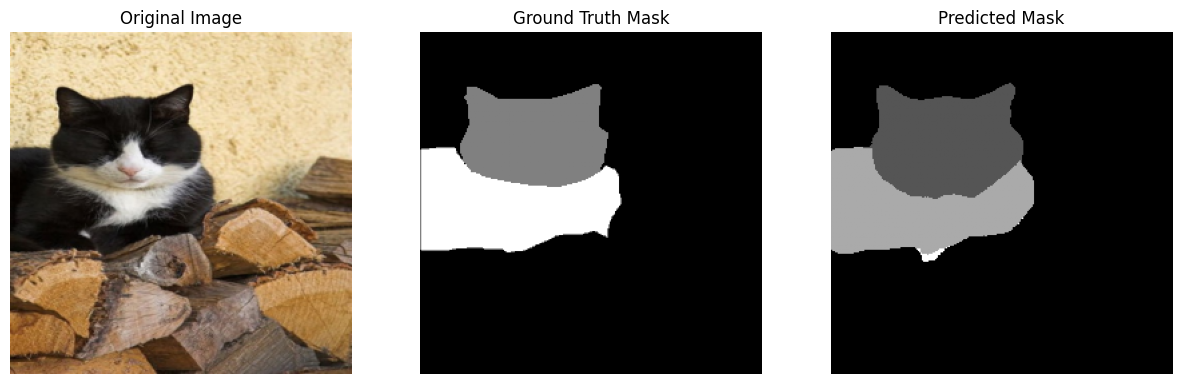

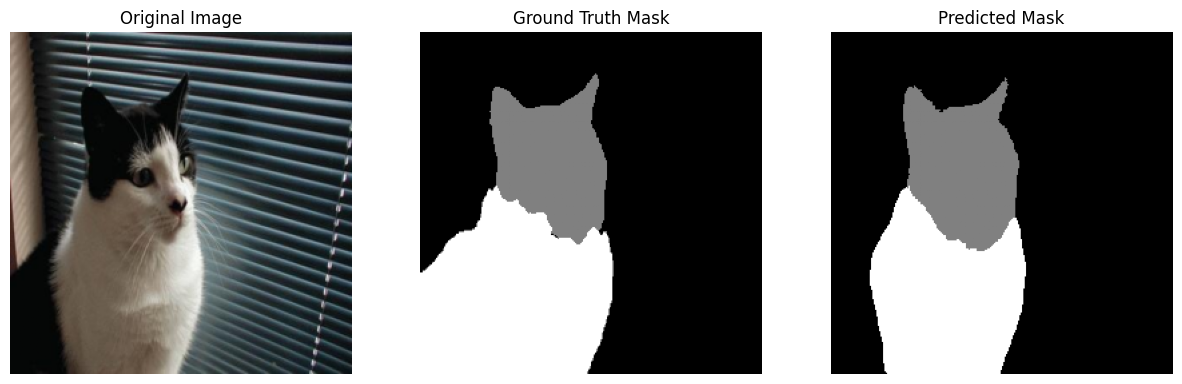

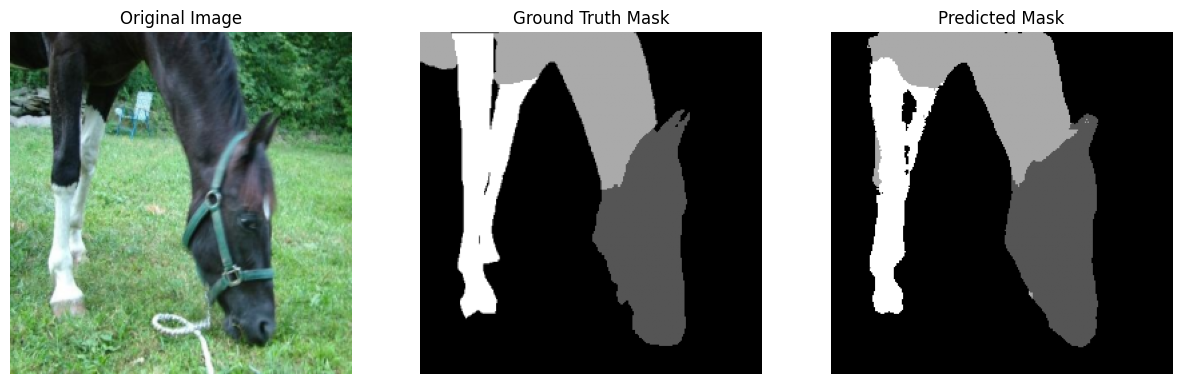

In [45]:
import numpy as np
import random
import matplotlib.pyplot as plt




# Function to denormalize images
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])  # ImageNet std
    img = img.numpy().transpose(1, 2, 0)  # Convert to HWC
    img = img * std + mean  # Reverse normalization
    img = np.clip(img, 0, 1)  # Clip values to [0,1]
    return img

# Set model to evaluation mode
model.eval()

# Get some test samples
test_samples = random.sample(range(len(test_dataset)), 5)

for idx in test_samples:
    img, mask = test_dataset[idx]

    with torch.no_grad():
        pred_mask = model(img.unsqueeze(0).to(device))  # Forward pass

    # Convert logits to class predictions by taking argmax along the channel dimension
    pred_mask = pred_mask.argmax(dim=1).cpu().squeeze().numpy()  # Take argmax to get class indices, then squeeze batch dim

    # Display images
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original Image (Denormalized)
    axes[0].imshow(img.permute(1, 2, 0))

    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Ground Truth Mask
    axes[1].imshow(mask.squeeze(), cmap="gray")
    axes[1].set_title("Ground Truth Mask")

    axes[1].axis("off")

    # Predicted Mask
    axes[2].imshow(pred_mask, cmap="gray")
    axes[2].set_title("Predicted Mask")
    axes[2].axis("off")

    plt.show()